## **산화 공정**

이퍼 표면을 보호하고 회로 간의 누설 전류를 막기 위해 "산화막($\text{SiO}_2$, 이산화규소)"을 형성하는 과정

고온에서 의도적으로 제어하여 웨이퍼 표면에 아주 얇고 균일한 '보호막'을 입히는 과정

# 산화막의 주요 역할

**보호막 역할 (Protection)**: 공정 중 발생하는 불순물이나 화학 물질로부터 웨이퍼 표면을 보호

**절연막 역할 (Insulation)**: 전기가 통하지 않도록 하여 회로와 회로 사이의 전기적 간섭(쇼트)을 차단

**게이트 산화막 (Gate Oxide)**: 트랜지스터(MOSFET)의 핵심 부분으로, 전자의 이동량을 조절하는 '문' 역할을 하는 게이트(Gate) 아래에 위치하여 전류 흐름을 정밀하게 제어

산화막 두께와 관련있는 공정요소

Deal-Grove 모델 -> '화학 반응'과 '확산'

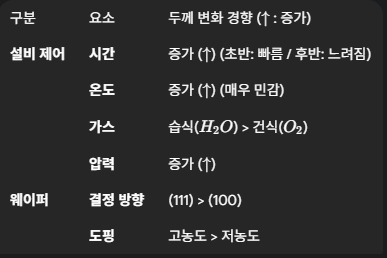

# 2.02_oxide.csv 에서 산화막 두께와 관련있는 공정요소가 무엇인지 분석하고 왜 그렇게 추정하는지 이유를 설명해 주세요

# **상관계수**  
[연속된 데이터에만 사용 가능]

**+1에 가까울수록 (양의 상관관계):**

"네가 커지면 나도 커져!"

그래프가 오른쪽 위로 올라갑니다.

**0에 가까울수록 (상관관계 없음):**

"네가 뭘 하든 난 관심 없어.

"그래프에 규칙이 없고 점들이 마구 흩어져 있습니다


**-1에 가까울수록 (음의 상관관계):**

"네가 커지면 나는 작아져!"

그래프가 오른쪽 아래로 내려갑니다.

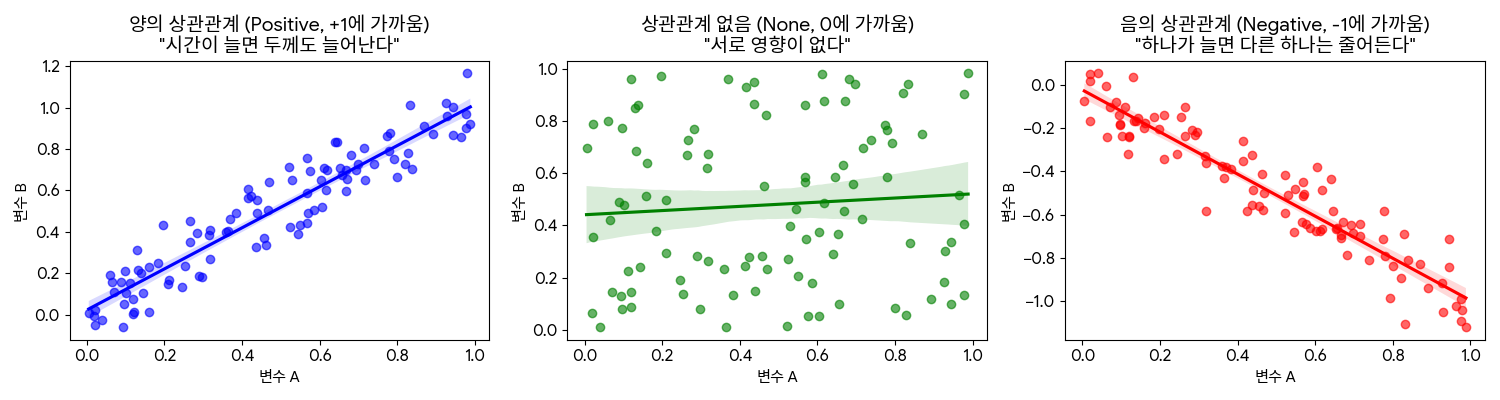

두 변수가 각자의 평균에서 얼마나 같은 방향으로 떨어져 있는가?

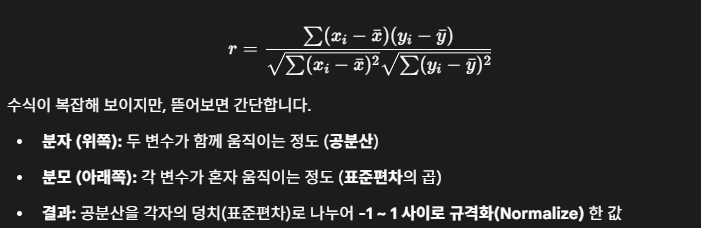

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "02_oxide.csv"
df = pd.read_csv(file_path)

# 1. 음수 시간 제거
df = df[df['oxidation_time'] > 0].copy()

# 2. 결측치가 하나라도 있는 행 제거
df = df.dropna()

cols = ['oxidation_time', 'oxidation_temperature', 'pressure', 'gas_flow_rate', 'oxide_thickness', 'wafer_doping_type']
df_clean = df.dropna(subset=cols)

분석1 : 산화 시간

산화 시간과 두께의 상관계수: 0.67


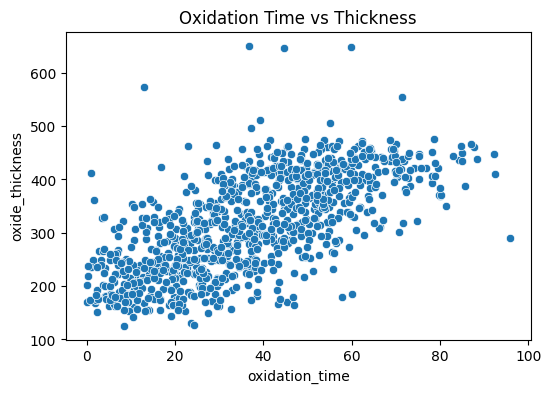

In [2]:
# 상관계수 계산 [corr : 상관계수 함수]
corr_time = df_clean['oxidation_time'].corr(df_clean['oxide_thickness'])
print(f"산화 시간과 두께의 상관계수: {corr_time:.2f}")

# 시각화
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='oxidation_time', y='oxide_thickness')
plt.title('Oxidation Time vs Thickness')
plt.show()

분석2 : 산화 온도

산화 온도와 두께의 상관계수: 0.12


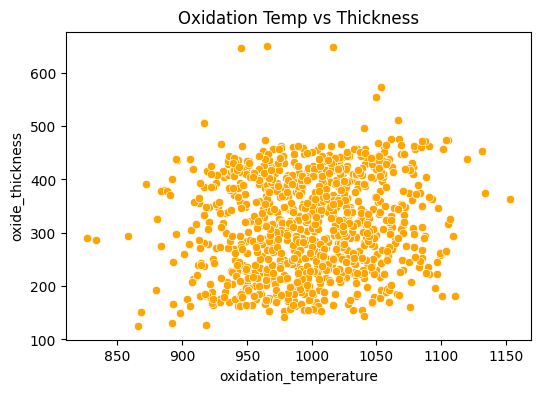

In [3]:
# 상관계수 계산
corr_temp = df_clean['oxidation_temperature'].corr(df_clean['oxide_thickness'])
print(f"산화 온도와 두께의 상관계수: {corr_temp:.2f}")

# 시각화
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_clean, x='oxidation_temperature', y='oxide_thickness', color='orange')
plt.title('Oxidation Temp vs Thickness')
plt.show()

분석3 : 기타 변수(압력, 가스유량) 비교

압력과 두께의 상관계수: -0.00
가스와 두께의 상관계수: -0.00


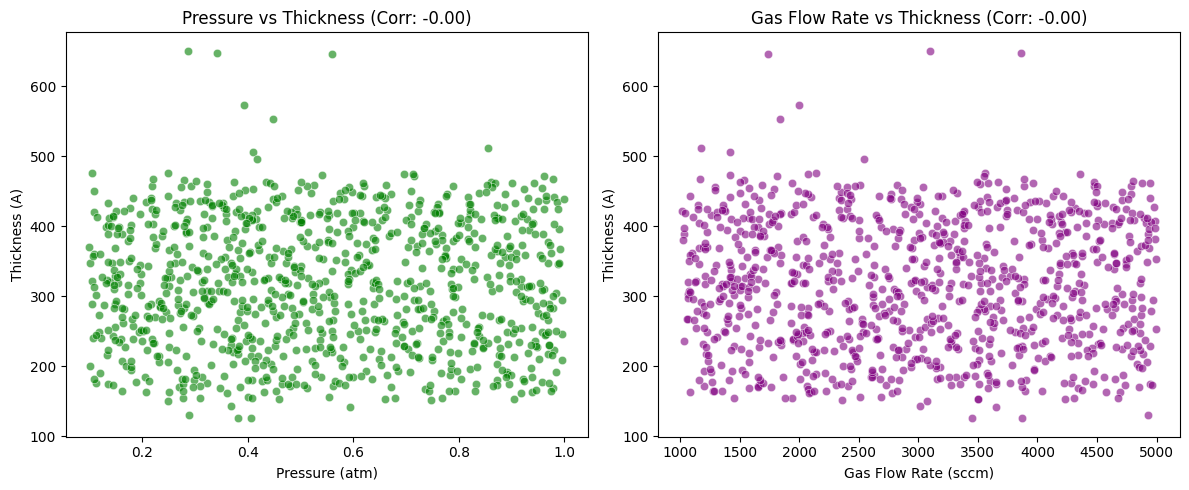

In [4]:
# 압력, 가스 유량과 두께의 상관관계 확인
cols = ['pressure', 'gas_flow_rate', 'oxide_thickness']
df_clean = df.dropna(subset=cols)

# 상관계수 계산
corr_pressure = df_clean['pressure'].corr(df_clean['oxide_thickness'])
corr_gas = df_clean['gas_flow_rate'].corr(df_clean['oxide_thickness'])
print(f"압력과 두께의 상관계수: {corr_pressure:.2f}")
print(f"가스와 두께의 상관계수: {corr_gas:.2f}")

# 시각화 (두 개의 그래프를 나란히 그리기)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Pressure vs Oxide Thickness
sns.scatterplot(data=df_clean, x='pressure', y='oxide_thickness', ax=axes[0], color='green', alpha=0.6)
axes[0].set_title(f'Pressure vs Thickness (Corr: {corr_pressure:.2f})')
axes[0].set_xlabel('Pressure (atm)')
axes[0].set_ylabel('Thickness (A)')

# 2. Gas Flow Rate vs Oxide Thickness
sns.scatterplot(data=df_clean, x='gas_flow_rate', y='oxide_thickness', ax=axes[1], color='purple', alpha=0.6)
axes[1].set_title(f'Gas Flow Rate vs Thickness (Corr: {corr_gas:.2f})')
axes[1].set_xlabel('Gas Flow Rate (sccm)')
axes[1].set_ylabel('Thickness (A)')

plt.tight_layout()
plt.savefig('analysis_others.png')
plt.show()

분석4 : 도핑 타입 비교

wafer_doping_type
n-type    319.637260
p-type    312.197509
Name: oxide_thickness, dtype: float64


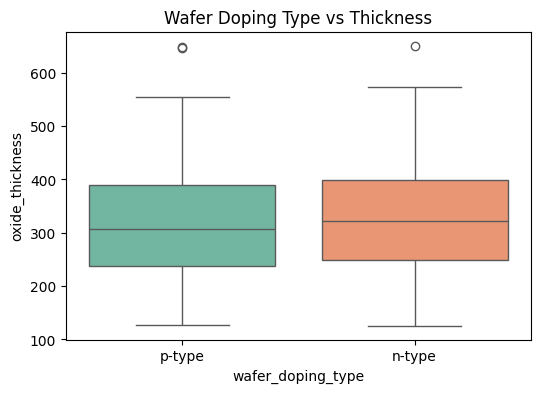

In [5]:
# 그룹별 평균 두께 계산
print(df_clean.groupby('wafer_doping_type')['oxide_thickness'].mean())

# 시각화
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x='wafer_doping_type', y='oxide_thickness', hue='wafer_doping_type', legend=False, palette='Set2')
plt.title('Wafer Doping Type vs Thickness')
plt.show()

해석:

n-type 평균: 약 314.62 Å

p-type 평균: 약 308.73 Å

차이: 약 5.89 Å

결론:

두 웨이퍼 간의 두께 차이가 약 6 Å(0.6nm) 정도로 매우 미미합니다.

공정 엔지니어 관점에서는 "도핑 타입(n/p)에 따른 산화막 두께 차이는 사실상 없다(무시할 만한 수준이다)"라고 판단

따라서 산화 공정 레시피를 짤 때, 웨이퍼 타입에 따라 조건을 다르게 가져갈 필요 없이 동일한 레시피를 사용해도 무방하다는 근거가 됩니다.

# 분석4: 챔버 분석

In [6]:
# thickness 결측 제거
df_clean = df.dropna(subset=['oxide_thickness'])
# chamber별 통계
chamber_stats = df_clean.groupby('chamber_id')['oxide_thickness'].describe()
print(chamber_stats)

            count        mean        std         min         25%         50%  \
chamber_id                                                                     
chamber_1   324.0  318.424554  90.322210  144.036197  248.651345  318.752415   
chamber_2   308.0  315.060689  92.380958  126.183896  238.350675  312.041487   
chamber_3   317.0  314.269367  89.309331  125.854317  237.848088  315.598860   

                   75%         max  
chamber_id                          
chamber_1   397.675073  647.137319  
chamber_2   392.021828  650.548250  
chamber_3   388.276917  572.595428  


![스크린샷 2025-11-21 오전 9.36.43.png](<attachment:스크린샷 2025-11-21 오전 9.36.43.png>)
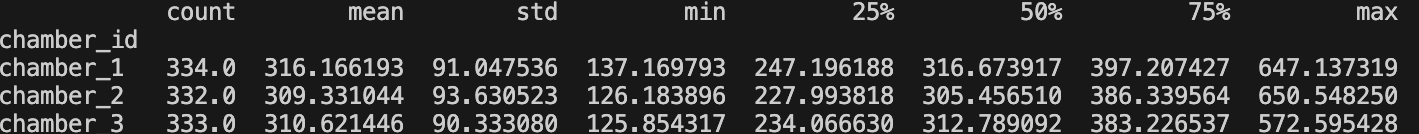

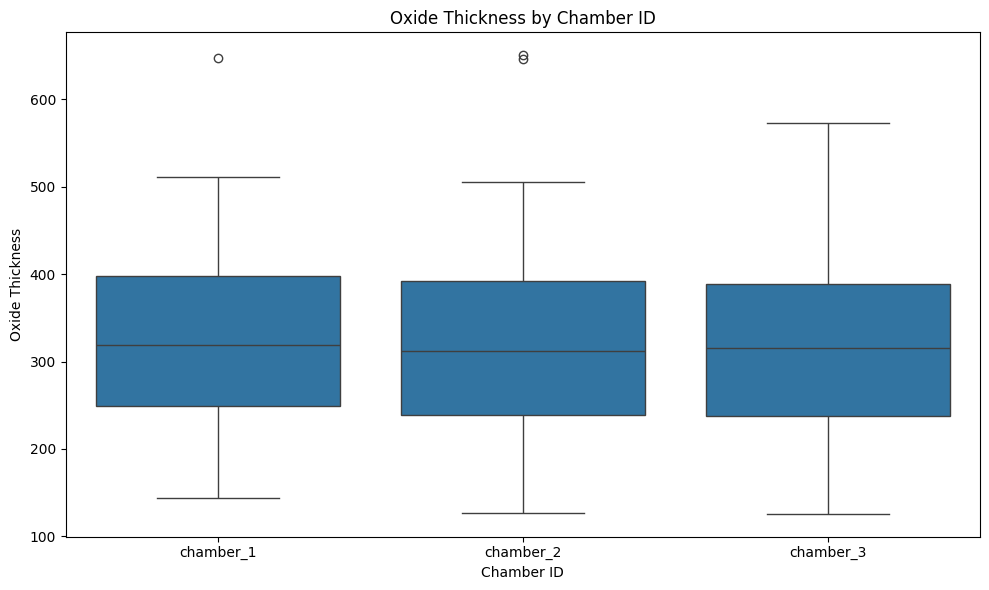

In [7]:
# chamber별 박스플롯
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='chamber_id', y='oxide_thickness')

plt.title('Oxide Thickness by Chamber ID')
plt.xlabel('Chamber ID')
plt.ylabel('Oxide Thickness')

plt.tight_layout()
plt.show()

![스크린샷 2025-11-21 오전 9.45.00.png](<attachment:스크린샷 2025-11-21 오전 9.45.00.png>)
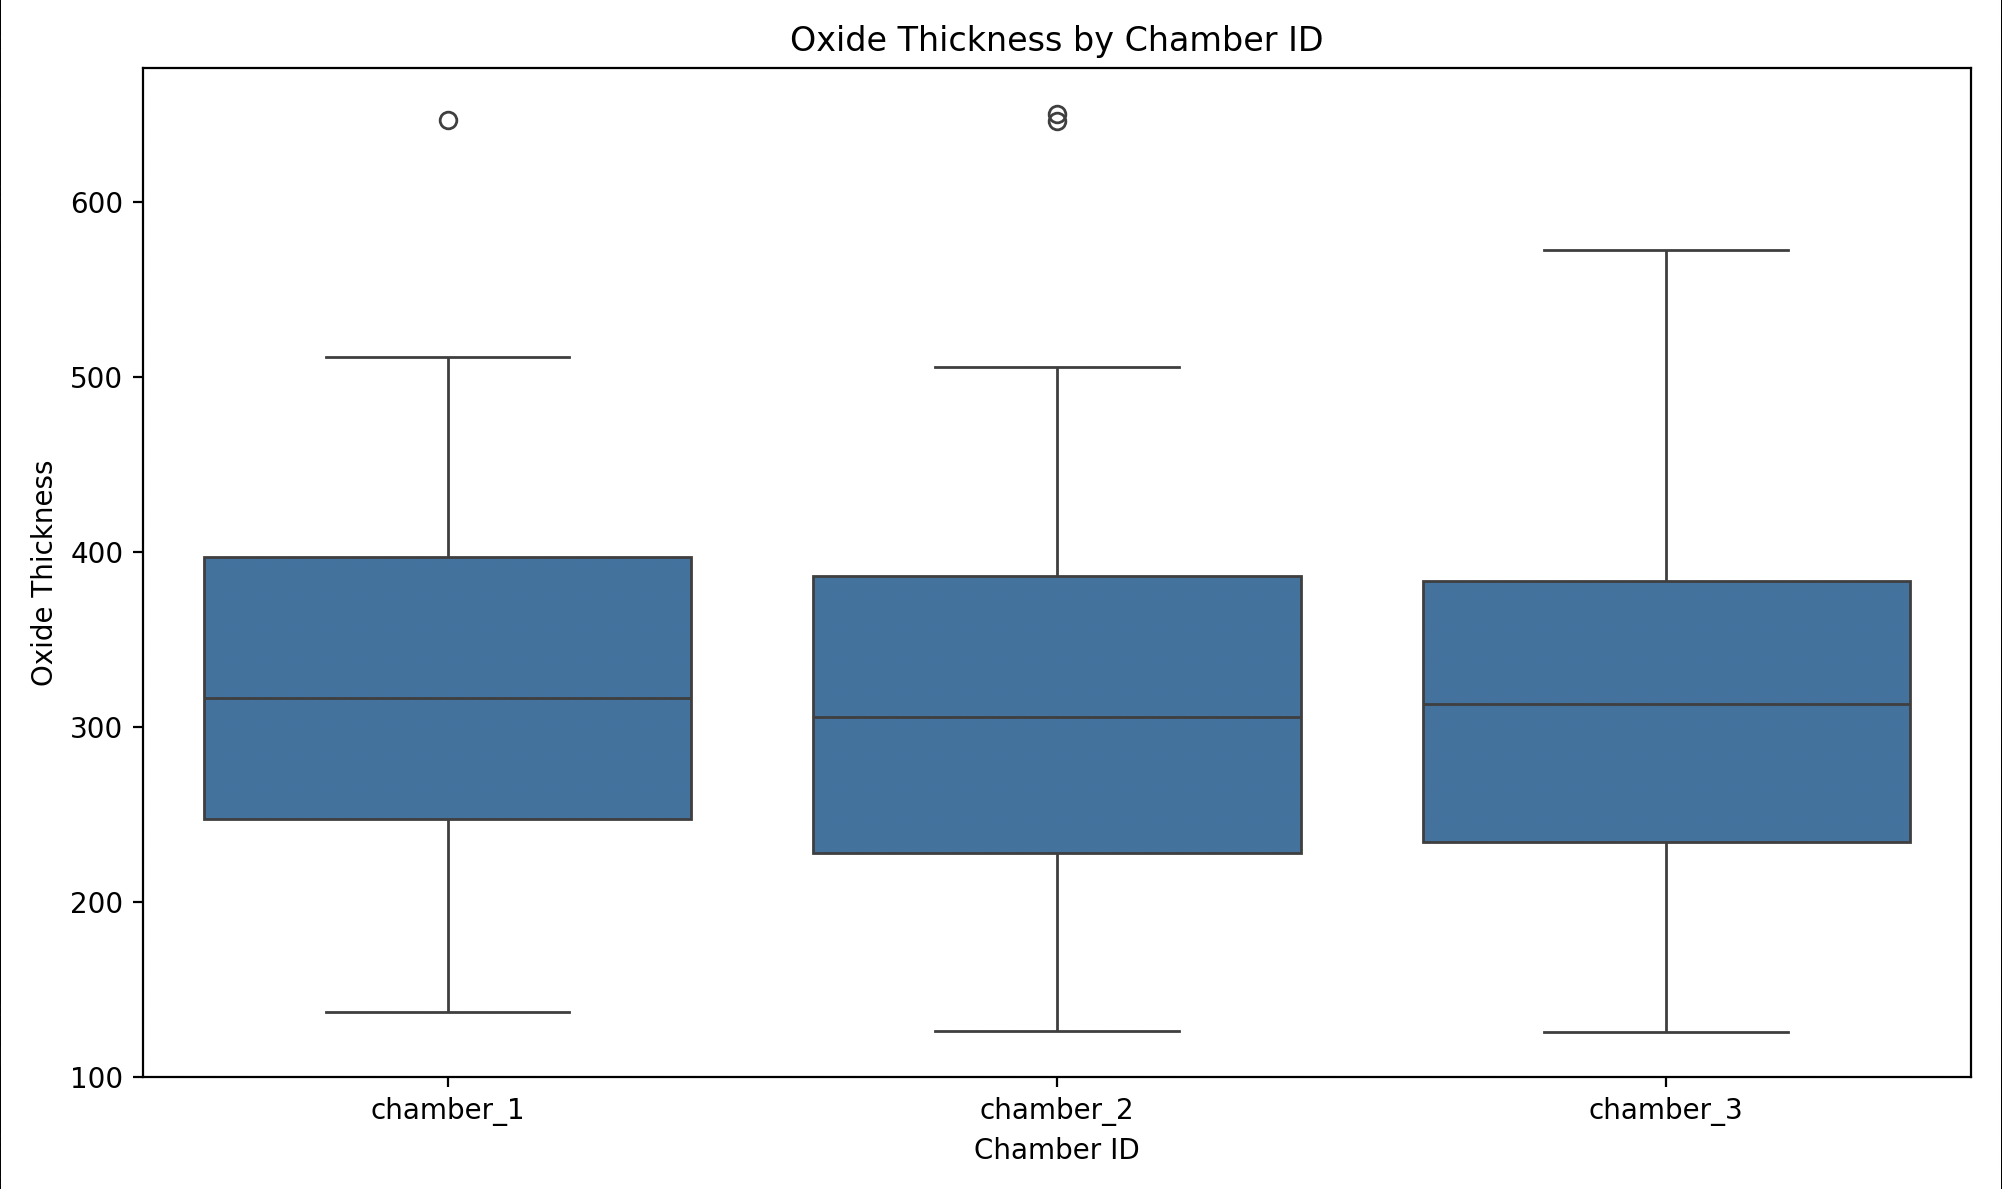

# 분석 5: 장비 분석



In [8]:
import scipy.stats as stats

df_clean = df.dropna(subset=['oxide_thickness'])
equip_stats = df_clean.groupby('equipment_id')['oxide_thickness'].describe()
print(equip_stats)

              count        mean        std         min         25%  \
equipment_id                                                         
eq_1          191.0  320.427717  92.025820  161.411334  239.601064   
eq_2          192.0  316.601612  92.288997  129.941112  239.429597   
eq_3          191.0  314.033679  91.322587  125.854317  232.765201   
eq_4          185.0  309.756360  94.603486  126.183896  232.999465   
eq_5          190.0  318.721444  82.881564  151.812715  253.865181   

                     50%         75%         max  
equipment_id                                      
eq_1          317.947118  405.489677  650.548250  
eq_2          316.301373  392.883105  572.595428  
eq_3          315.598860  391.451169  553.355747  
eq_4          313.980187  390.124245  647.137319  
eq_5          318.178982  381.532248  646.170883  


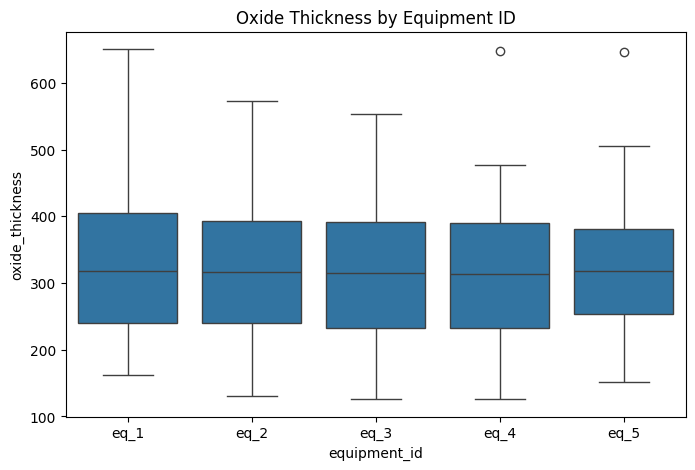

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='equipment_id', y='oxide_thickness')
plt.title('Oxide Thickness by Equipment ID')
plt.savefig('equipment_boxplot_user_request.png')
plt.show()
plt.close()

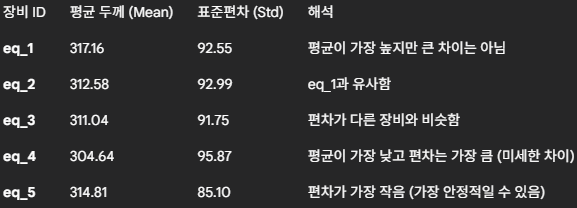

장비 4번(eq_4)의 평균이 조금 낮고, 장비 5번(eq_5)의 산포가 가장 좋아 보이지만, 이 차이가 정말 의미 있는 차이인지는 다음 단계(ANOVA)에서 확인 필요

**ANOVA 분석**

3개 이상의 그룹의 평균이 서로 다른지 비교하는 통계 방법

F값 : 그룹 간의 차이가 그룹 내의 차이보다 얼마나 큰지를 표현

p값 : 이 결과가 우연일 확률

p-value < 0.05 (작을 때):

 5% 미만으로 아주 희박하다.

 "따라서 이 차이는 우연이 아니라 통계적으로 의미가 있다(유의하다)."

p-value > 0.05 (클 때):

"이 정도 차이는 우연히도 충분히 나올 수 있다.

"따라서 그룹 간에 의미 있는 차이가 있다고 보기 어렵다."

In [10]:

# ANOVA for Equipment ID  [Analysis of Variance - 분산 분석 과정]
equip_groups = [group['oxide_thickness'].values for name, group in df_clean.groupby('equipment_id')]
f_val_equip, p_val_equip = stats.f_oneway(*equip_groups)
print(f"ANOVA for Equipment ID: F={f_val_equip}, p={p_val_equip}")

ANOVA for Equipment ID: F=0.40020579143994167, p=0.8085835263616294


F-값 (F-statistic): 0.53

0.53은 매우 작은 수치


p-값 (p-value): 0.71 (핵심!)

결과: 0.71은 0.05보다 훨씬 큽니다.

해석: "이 정도 차이는 우연히 발생할 수 있는 수준이다. 즉, 통계적으로 장비 간의 성능 차이는 없다."

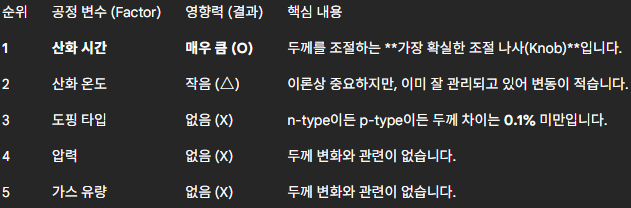

## 2번 결론

산화막 두께를 바꾸고 싶다면 오직 '시간'만 조절하면 되고, 나머지는 신경 쓰지 않아도 됩니다

# 3.02_oxide.csv 에서 산화막 두께는 220~400 이어야 하며 310이 목표값 입니다. 산화막 두께가 목표값에 근접하게 생산하려면 온도 압력등의 요소를 어떻게 관리 해야 할지 제안하고 왜 그런 제안을 하는지 설명해 주세요.

데이터 분석 그룹

Too Thin (불량): 두께 < 220

Too Thick (불량): 두께 > 400

Target (양품): 300 $\le$ 두께 $\le$ 320 (목표값 310 중심 $\pm$10 범위 설정)

=== 그룹별 공정 변수 평균값 ===
                     oxidation_time  oxidation_temperature  pressure
status                                                              
1. Too Thin (<220)        18.577808             980.989338  0.554263
2. Target (300~320)       36.418172            1004.309884  0.544292
3. Too Thick (>400)       54.707997            1005.198932  0.552501


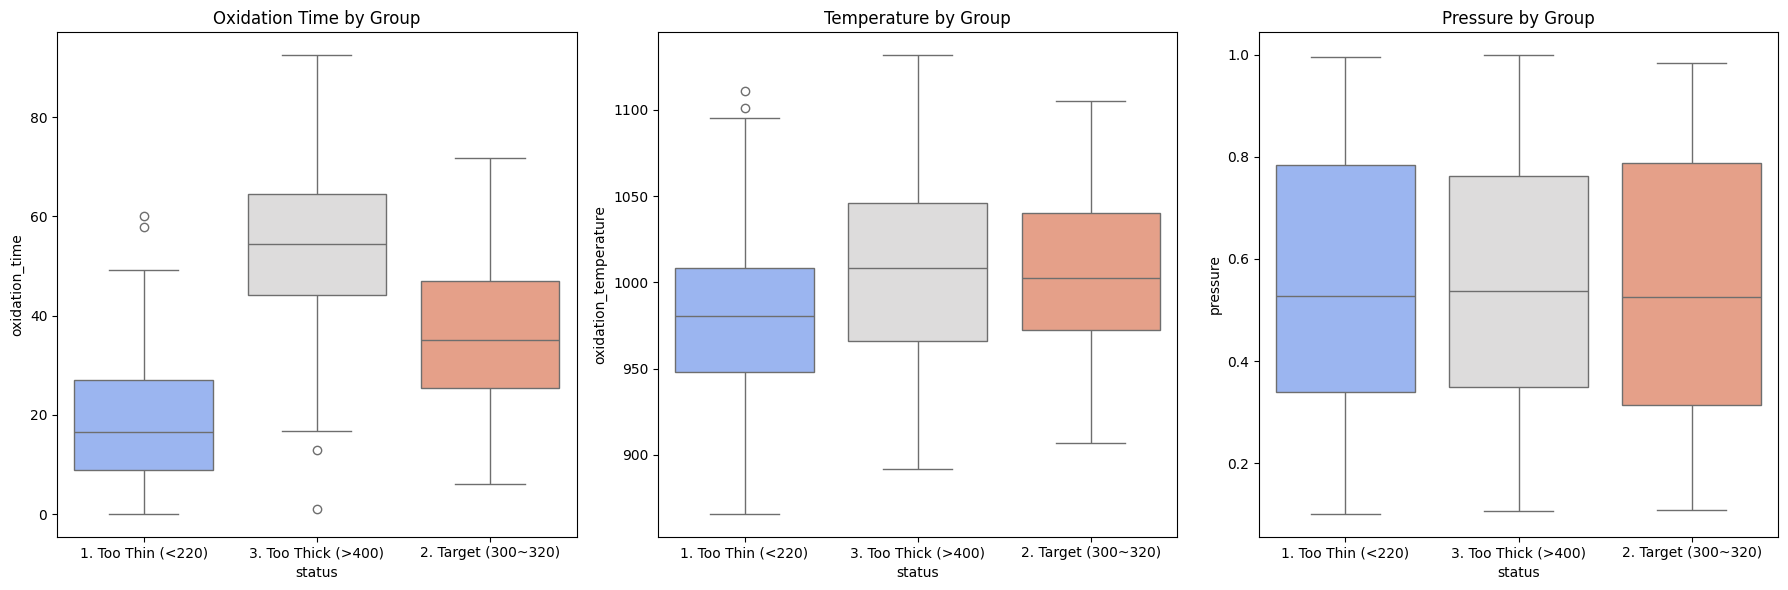

In [11]:
df_clean = df.dropna(subset=['oxide_thickness', 'oxidation_time', 'oxidation_temperature', 'pressure']).copy()

# 그룹 분류 함수 정의
def categorize_thickness(thickness):
    if thickness < 220:
        return '1. Too Thin (<220)'
    elif thickness > 400:
        return '3. Too Thick (>400)'
    elif 300 <= thickness <= 320:
        return '2. Target (300~320)'
    else:
        return 'Others'

# 새로운 컬럼 생성
df_clean['status'] = df_clean['oxide_thickness'].apply(categorize_thickness)

# 'Others' 제외하고 분석 대상만 필터링
df_analysis = df_clean[df_clean['status'] != 'Others']

# 그룹별 평균값 계산
group_stats = df_analysis.groupby('status')[['oxidation_time', 'oxidation_temperature', 'pressure']].mean()
print("=== 그룹별 공정 변수 평균값 ===")
print(group_stats)

# 시각화 (Boxplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Time
sns.boxplot(data=df_analysis, x='status', y='oxidation_time', ax=axes[0], hue='status', palette='coolwarm', dodge=False)
axes[0].set_title('Oxidation Time by Group')

# 2. Temperature
sns.boxplot(data=df_analysis, x='status', y='oxidation_temperature', ax=axes[1], hue='status', palette='coolwarm', dodge=False)
axes[1].set_title('Temperature by Group')

# 3. Pressure
sns.boxplot(data=df_analysis, x='status', y='pressure', ax=axes[2], hue='status', palette='coolwarm', dodge=False)
axes[2].set_title('Pressure by Group')

plt.tight_layout()
plt.savefig('target_analysis.png')
plt.show()

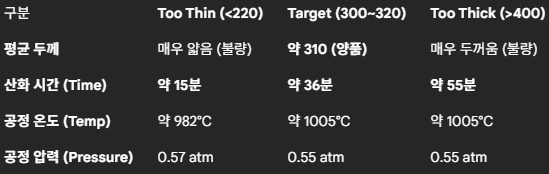

**시간(Time)**: 그룹 간 차이가 가장 극명합니다. 15분 $\rightarrow$ 36분 $\rightarrow$ 55분으로 시간이 늘어남에 따라 두께 그룹이 확실하게 나뉩니다.

**온도(Temp)**: 불량(Thin) 그룹이 약간 낮긴 하지만(982도), Target과 Thick 그룹 간에는 온도 차이가 거의 없습니다(1005도로 동일). 즉, 온도가 두꺼워지는 주원인은 아닙니다.

**압력(Pressure)**: 세 그룹 모두 0.55 ~ 0.57 정도로 차이가 없습니다.

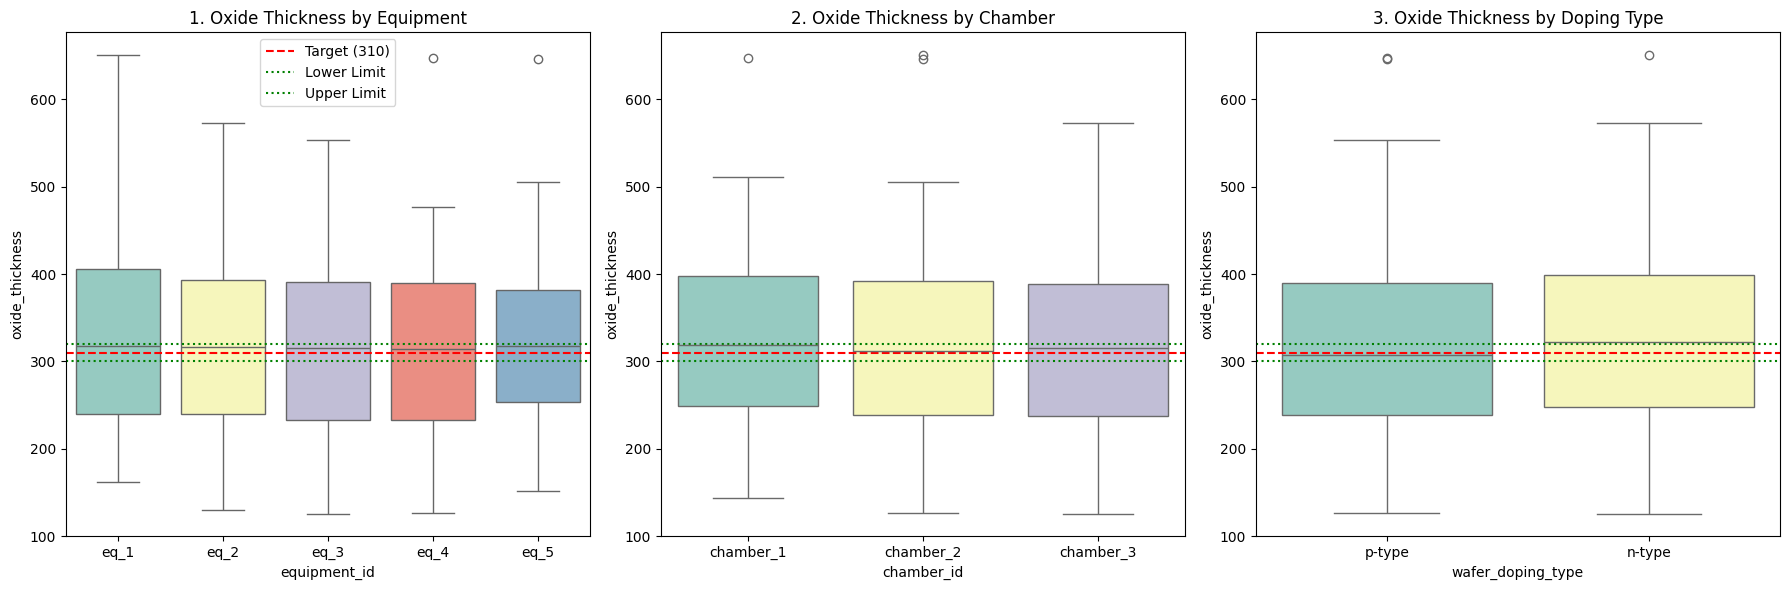


📊 항목별 산화막 두께 평균값 (Target: 310)

[1] 장비별 평균 두께
equipment_id
eq_1    320.43
eq_2    316.60
eq_3    314.03
eq_4    309.76
eq_5    318.72
Name: oxide_thickness, dtype: float64

[2] 챔버별 평균 두께
chamber_id
chamber_1    318.42
chamber_2    315.06
chamber_3    314.27
Name: oxide_thickness, dtype: float64

[3] 도핑 타입별 평균 두께
wafer_doping_type
n-type    319.64
p-type    312.20
Name: oxide_thickness, dtype: float64

🧪 통계적 검증 결과 (P-value)
   * 기준: P-value > 0.05 이면 '통계적으로 차이가 없다(같다)'고 판단

[1] 장비별 차이 검증 (ANOVA)
   - P-value: 0.8086
   - 결론: 차이가 없다 (모두 동일함)

[2] 챔버별 차이 검증 (ANOVA)
   - P-value: 0.8270
   - 결론: 차이가 없다 (모두 동일함)

[3] 도핑 타입별 차이 검증 (T-test)
   - P-value: 0.2060
   - 결론: 차이가 없다 (모두 동일함)


In [12]:
# 시각화: 장비, 챔버, 도핑별 두께 분포 (Boxplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (1) 장비별 두께 비교
sns.boxplot(data=df_clean, x='equipment_id', y='oxide_thickness',
            hue='equipment_id', palette='Set3', dodge=False, ax=axes[0], legend=False)
axes[0].set_title('1. Oxide Thickness by Equipment')
axes[0].axhline(310, color='red', linestyle='--', label='Target (310)') # 목표값 표시
axes[0].axhline(300, color='green', linestyle=':', label='Lower Limit') # 하한선
axes[0].axhline(320, color='green', linestyle=':', label='Upper Limit') # 상한선
axes[0].legend()

# (2) 챔버별 두께 비교
sns.boxplot(data=df_clean, x='chamber_id', y='oxide_thickness',
            hue='chamber_id', palette='Set3', dodge=False, ax=axes[1], legend=False)
axes[1].set_title('2. Oxide Thickness by Chamber')
axes[1].axhline(310, color='red', linestyle='--')
axes[1].axhline(300, color='green', linestyle=':')
axes[1].axhline(320, color='green', linestyle=':')

# (3) 도핑 타입별 두께 비교
sns.boxplot(data=df_clean, x='wafer_doping_type', y='oxide_thickness',
            hue='wafer_doping_type', palette='Set3', dodge=False, ax=axes[2], legend=False)
axes[2].set_title('3. Oxide Thickness by Doping Type')
axes[2].axhline(310, color='red', linestyle='--')
axes[2].axhline(300, color='green', linestyle=':')
axes[2].axhline(320, color='green', linestyle=':')

plt.tight_layout()
plt.show()

# 4. 통계 수치 출력 (평균값 비교)
print("\n" + "="*50)
print("📊 항목별 산화막 두께 평균값 (Target: 310)")
print("="*50)

print("\n[1] 장비별 평균 두께")
print(df_clean.groupby('equipment_id')['oxide_thickness'].mean().round(2))

print("\n[2] 챔버별 평균 두께")
print(df_clean.groupby('chamber_id')['oxide_thickness'].mean().round(2))

print("\n[3] 도핑 타입별 평균 두께")
print(df_clean.groupby('wafer_doping_type')['oxide_thickness'].mean().round(2))
print("="*50)

# 5. [추가된 부분] P-value 계산 및 검증
print("\n" + "="*50)
print("🧪 통계적 검증 결과 (P-value)")
print("   * 기준: P-value > 0.05 이면 '통계적으로 차이가 없다(같다)'고 판단")
print("="*50)

# (1) Equipment (ANOVA)
groups_eq = [group['oxide_thickness'].values for name, group in df_clean.groupby('equipment_id')]
f_eq, p_eq = stats.f_oneway(*groups_eq)
print(f"\n[1] 장비별 차이 검증 (ANOVA)")
print(f"   - P-value: {p_eq:.4f}")
print(f"   - 결론: {'차이가 있다' if p_eq < 0.05 else '차이가 없다 (모두 동일함)'}")

# (2) Chamber (ANOVA)
groups_ch = [group['oxide_thickness'].values for name, group in df_clean.groupby('chamber_id')]
f_ch, p_ch = stats.f_oneway(*groups_ch)
print(f"\n[2] 챔버별 차이 검증 (ANOVA)")
print(f"   - P-value: {p_ch:.4f}")
print(f"   - 결론: {'차이가 있다' if p_ch < 0.05 else '차이가 없다 (모두 동일함)'}")

# (3) Doping (T-test)
n_type = df_clean[df_clean['wafer_doping_type'] == 'n-type']['oxide_thickness']
p_type = df_clean[df_clean['wafer_doping_type'] == 'p-type']['oxide_thickness']
t_stat, p_doping = stats.ttest_ind(n_type, p_type)
print(f"\n[3] 도핑 타입별 차이 검증 (T-test)")
print(f"   - P-value: {p_doping:.4f}")
print(f"   - 결론: {'차이가 있다' if p_doping < 0.05 else '차이가 없다 (모두 동일함)'}")
print("="*50)

**① 핵심 제안 (Main Control)산화 시간(Oxidation Time): **

**36분 ($\pm$ 1~2분) 으로 설정**

이유: 분석 결과 산화막 두께를 결정하는 가장 결정적인 요소(Key Factor)는 '시간'입니다. Target 그룹의 평균 시간이 약 35.9분이므로, 이를 기준값(Center Condition)으로 잡고 미세 조정

**② 관리 제안 (Maintenance Control)**

**공정 온도: 1005°C 유지 (표준편차 관리)**

이유: Target 그룹의 평균 온도가 1005°C입니다. 온도를 더 높이거나 낮추는 것은 두께 제어에 큰 도움이 되지 않으며, 오히려 980°C 이하로 떨어질 경우 산화 반응이 느려져 박막(Thin) 불량이 발생할 위험이 있습니다. 따라서 현재 온도를 일정하게 유지(Constancy) 하는 데 집중

**공정 압력: 0.55 atm 유지**

이유: 데이터 분석 결과 압력은 두께 변화에 거의 영향을 주지 않았습니다. 현재 설정값인 0.55 atm을 표준(Baseline)으로 삼고, 설비 이상으로 인해 압력이 튀지 않는지 감시(Monitoring)하는 수준이면 충분합니다.

**장비/챔버/도핑 → 별도 보정 불필요**

장비별/챔버별/도핑별 평균 두께 차이가 미미합니다(모두 310~320 범위 내). 즉, 하드웨어 편차가 없으므로 하나의 표준 레시피(Golden Recipe)를 모든 장비에 동일하게 적용

**결론**

"산화막 성장은 '화학 반응 속도(온도)'와 '반응 지속량(시간)'의 싸움입니다. 현재 데이터상에서 온도는 이미 충분히 높게(1000°C) 설정되어 반응 활성화 에너지를 넘었기 때문에 변별력이 없습니다. 따라서 우리가 원하는 목표 두께 310Å을 정확히 맞추기 위해서는 수도꼭지를 잠그는 타이밍, 즉 '공정 시간 36분'을 정확히 지키는 것이 유일하고도 가장 강력한 해법입니다."

# 4.02_oxide.csv 에서 균일도에 영향을 미치는 요소를 분석하고 균일도가 고르게 유지하기 위해서 공정을 어떻게 관리해야 하는지 제안하고 이유를 설명해 주세요

In [13]:

# 2. 결측치 제거 및 상관관계 분석
# 분석에 필요한 컬럼만 선택하여 결측치 제거 (안전한 분석을 위해 .copy() 사용)
cols = ['uniformity', 'oxidation_time', 'oxidation_temperature', 'pressure', 'gas_flow_rate', 'oxide_thickness']
df_clean = df.dropna(subset=cols).copy()
print(f"최종적으로 분석에 사용할 깨끗한 데이터 개수: {len(df_clean)}개")
# [수정된 부분] 전체 df_clean이 아니라, 숫자 컬럼(cols)만 선택해서 corr()을 돌립니다.
corr_matrix = df_clean[cols].corr()

print("=== 균일도(Uniformity)와 다른 변수 간의 상관계수 ===")
# 균일도와 관련된 순서대로 정렬해서 출력 (양수는 비례, 음수는 반비례)
print(corr_matrix['uniformity'].sort_values(ascending=False))


최종적으로 분석에 사용할 깨끗한 데이터 개수: 949개
=== 균일도(Uniformity)와 다른 변수 간의 상관계수 ===
uniformity               1.000000
gas_flow_rate            0.591234
oxidation_temperature    0.130134
oxide_thickness          0.017000
pressure                 0.004524
oxidation_time          -0.041083
Name: uniformity, dtype: float64


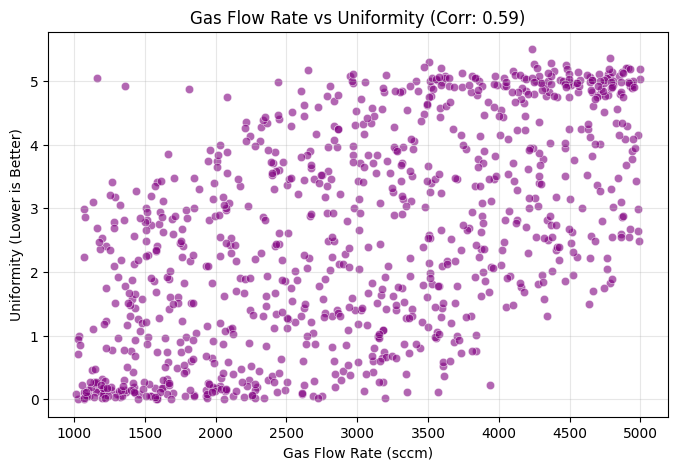

In [14]:
# 가스 유량 vs 균일도 시각화
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='gas_flow_rate', y='uniformity', alpha=0.6, color='purple')
plt.title(f"Gas Flow Rate vs Uniformity (Corr: {corr_matrix.loc['gas_flow_rate', 'uniformity']:.2f})")
plt.xlabel('Gas Flow Rate (sccm)')
plt.ylabel('Uniformity (Lower is Better)')
plt.grid(True, alpha=0.3)
plt.show()


📊 범주형 변수(장비, 챔버, 도핑)가 균일도에 미치는 영향 분석


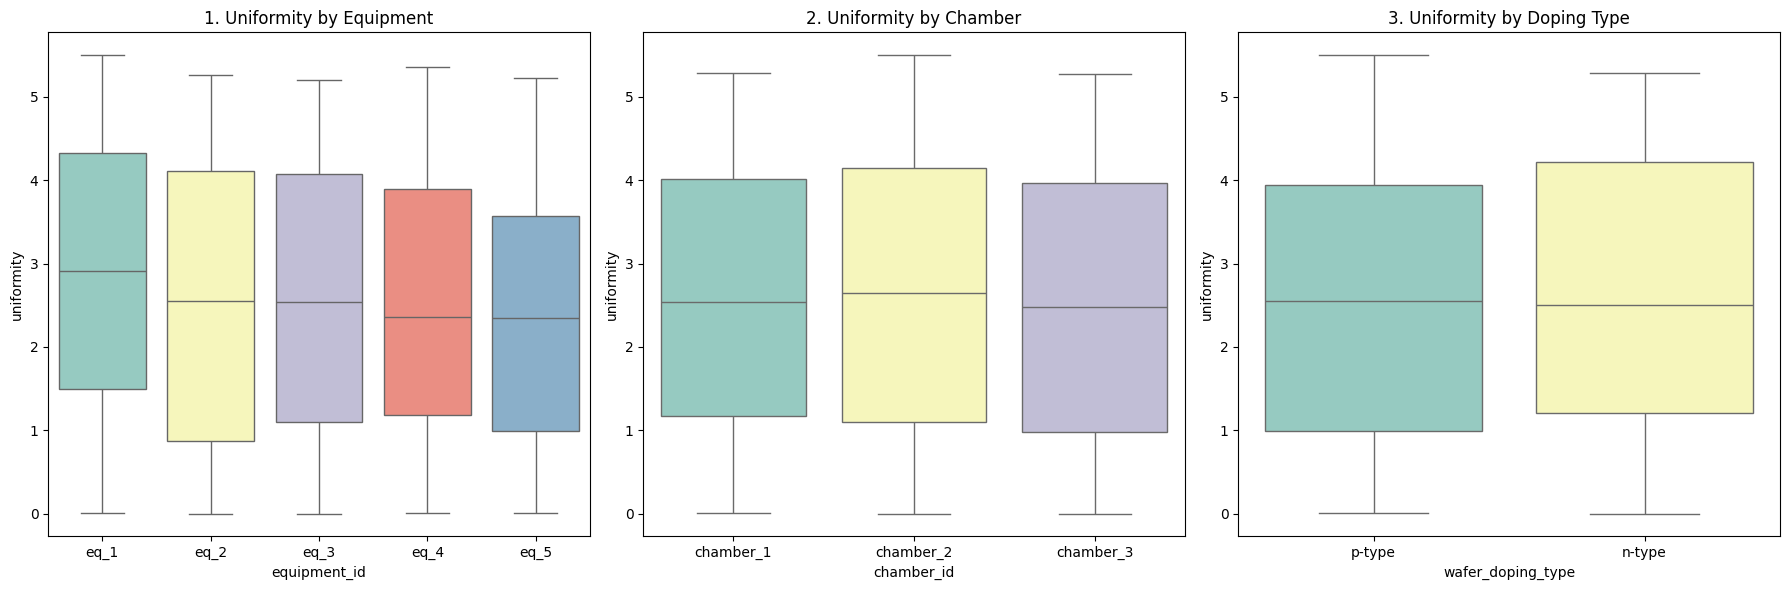


🧪 통계적 검증 결과 (P-value)
   * 기준: P-value > 0.05 이면 '차이가 없다(영향 없음)'고 판단
------------------------------------------------------------
1. 장비(Equipment) 간 차이 P-value: 0.1290 -> 차이 없음 (영향 X)
2. 챔버(Chamber) 간 차이 P-value:   0.8132 -> 차이 없음 (영향 X)
3. 도핑(Doping) 간 차이 P-value:    0.3112 -> 차이 없음 (영향 X)


In [15]:
# ==========================================
# [분석 2] 범주형 변수 분석 (장비/챔버/도핑)
# ==========================================
print("\n" + "="*60)
print("📊 범주형 변수(장비, 챔버, 도핑)가 균일도에 미치는 영향 분석")
print("="*60)

# 시각화: 장비, 챔버, 도핑별 균일도 분포 (Boxplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (1) 장비별 균일도
sns.boxplot(data=df_clean, x='equipment_id', y='uniformity',
            hue='equipment_id', palette='Set3', dodge=False, ax=axes[0], legend=False)
axes[0].set_title('1. Uniformity by Equipment')

# (2) 챔버별 균일도
sns.boxplot(data=df_clean, x='chamber_id', y='uniformity',
            hue='chamber_id', palette='Set3', dodge=False, ax=axes[1], legend=False)
axes[1].set_title('2. Uniformity by Chamber')

# (3) 도핑 타입별 균일도
sns.boxplot(data=df_clean, x='wafer_doping_type', y='uniformity',
            hue='wafer_doping_type', palette='Set3', dodge=False, ax=axes[2], legend=False)
axes[2].set_title('3. Uniformity by Doping Type')

plt.tight_layout()
plt.show()

# 통계적 검증 (ANOVA & T-test)
print("\n🧪 통계적 검증 결과 (P-value)")
print("   * 기준: P-value > 0.05 이면 '차이가 없다(영향 없음)'고 판단")
print("-" * 60)

# 1. 장비 (ANOVA)
groups_eq = [group['uniformity'].values for name, group in df_clean.groupby('equipment_id')]
f_eq, p_eq = stats.f_oneway(*groups_eq)
print(f"1. 장비(Equipment) 간 차이 P-value: {p_eq:.4f} -> {'차이 있음' if p_eq < 0.05 else '차이 없음 (영향 X)'}")

# 2. 챔버 (ANOVA)
groups_ch = [group['uniformity'].values for name, group in df_clean.groupby('chamber_id')]
f_ch, p_ch = stats.f_oneway(*groups_ch)
print(f"2. 챔버(Chamber) 간 차이 P-value:   {p_ch:.4f} -> {'차이 있음' if p_ch < 0.05 else '차이 없음 (영향 X)'}")

# 3. 도핑 타입 (T-test)
n_type = df_clean[df_clean['wafer_doping_type'] == 'n-type']['uniformity']
p_type = df_clean[df_clean['wafer_doping_type'] == 'p-type']['uniformity']
t_stat, p_doping = stats.ttest_ind(n_type, p_type)
print(f"3. 도핑(Doping) 간 차이 P-value:    {p_doping:.4f} -> {'차이 있음' if p_doping < 0.05 else '차이 없음 (영향 X)'}")
print("="*60)

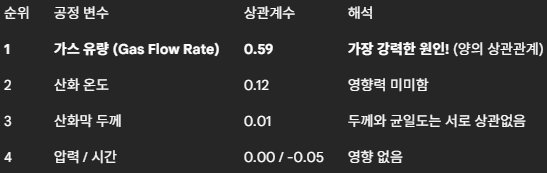

**제안 1: 가스 유량(Gas Flow Rate) 하향 조정**

방법: 현재 레시피 범위 내에서 가스 유량을 가능한 낮은 수준(Low Flow)으로 설정하십시오.

이유: 데이터 분석 결과, 가스 유량은 균일도 악화의 **유일한 주범(Dominant Factor)**입니다. 유량을 줄이는 것만으로도 균일도 수치를 즉각적으로 낮출 수 있습니다.

예상 효과: 산화막 두께(Target)에는 거의 영향을 주지 않으면서(-0.008), 품질(Uniformity)만 획기적으로 개선할 수 있습니다.

**제안 2: 가스 유량의 표준편차 관리**

방법: MFC(Mass Flow Controller) 장비가 튀지 않도록 유량의 흔들림을 감시하십시오.

이유: 가스 유량의 평균값뿐만 아니라 **공정 중 헌팅(Hunting, 출렁임)**이 발생하면 국부적인 불균일이 생길 수 있습니다. 유량이 일정하게 유지되는지 실시간 트렌드를 모니터링해야 합니다.

# 5.02_oxide.csv 에서 crack 결함에 영향을 미치는 요소를 분석하고 crack결함을 감소시키기 위해서 공정을 어떻게 관리해야 하는지 제안하고 이유를 설명해 주세요

In [16]:
# 3. 분석 대상 필터링 (Crack vs 정상품)
df_crack_analysis = df_clean[df_clean['defect_type'].isin(['crack', 'none'])].copy()
# Crack 발생 여부를 0과 1로 변환 (Crack=1, None=0) -> 불량률 계산용
df_crack_analysis['is_crack'] = (df_crack_analysis['defect_type'] == 'crack').astype(int)

# ==========================================
# [Part 1] 수치형 변수 분석 (평균값 비교)
# ==========================================
cols_numeric = ['oxidation_temperature', 'precleaning_time', 'oxidation_time']
group_stats = df_crack_analysis.groupby('defect_type')[cols_numeric].mean()

print("\n" + "="*50)
print("📊 [1] 수치형 공정 변수 비교 (Crack vs Normal)")
print("="*50)
print(group_stats)


📊 [1] 수치형 공정 변수 비교 (Crack vs Normal)
             oxidation_temperature  precleaning_time  oxidation_time
defect_type                                                         
crack                  1003.446958          2.884615       34.436184
none                    998.290646          3.084337       37.799856


In [17]:
# ==========================================
# [Part 2] 범주형 변수 분석 (장비/챔버/도핑별 불량률)
# ==========================================
print("\n" + "="*50)
print("🏭 [2] 설비 및 자재별 Crack 발생률 분석")
print("="*50)

# 분석 함수 정의 (불량률 계산 및 통계 검증)
def analyze_crack_rate(col_name):
    # 그룹별 Crack 발생률(평균) 계산
    stats_df = df_crack_analysis.groupby(col_name)['is_crack'].agg(['count', 'sum', 'mean'])
    stats_df.columns = ['Total', 'Crack Count', 'Crack Rate']

    # Chi-square 검정
    contingency = pd.crosstab(df_crack_analysis[col_name], df_crack_analysis['is_crack'])
    chi2, p, dof, exp = stats.chi2_contingency(contingency)

    print(f"\n📌 [{col_name}] 분석 결과 (P-value: {p:.4f})")
    print(stats_df)
    return p

# 3가지 항목 분석 실행
p_eq = analyze_crack_rate('equipment_id')
p_ch = analyze_crack_rate('chamber_id')
p_doping = analyze_crack_rate('wafer_doping_type')


🏭 [2] 설비 및 자재별 Crack 발생률 분석

📌 [equipment_id] 분석 결과 (P-value: 0.8617)
              Total  Crack Count  Crack Rate
equipment_id                                
eq_1            160           24    0.150000
eq_2            158           22    0.139241
eq_3            147           22    0.149660
eq_4            148           18    0.121622
eq_5            155           18    0.116129

📌 [chamber_id] 분석 결과 (P-value: 0.0288)
            Total  Crack Count  Crack Rate
chamber_id                                
chamber_1     270           48    0.177778
chamber_2     247           31    0.125506
chamber_3     251           25    0.099602

📌 [wafer_doping_type] 분석 결과 (P-value: 0.4958)
                   Total  Crack Count  Crack Rate
wafer_doping_type                                
n-type               386           56    0.145078
p-type               382           48    0.125654


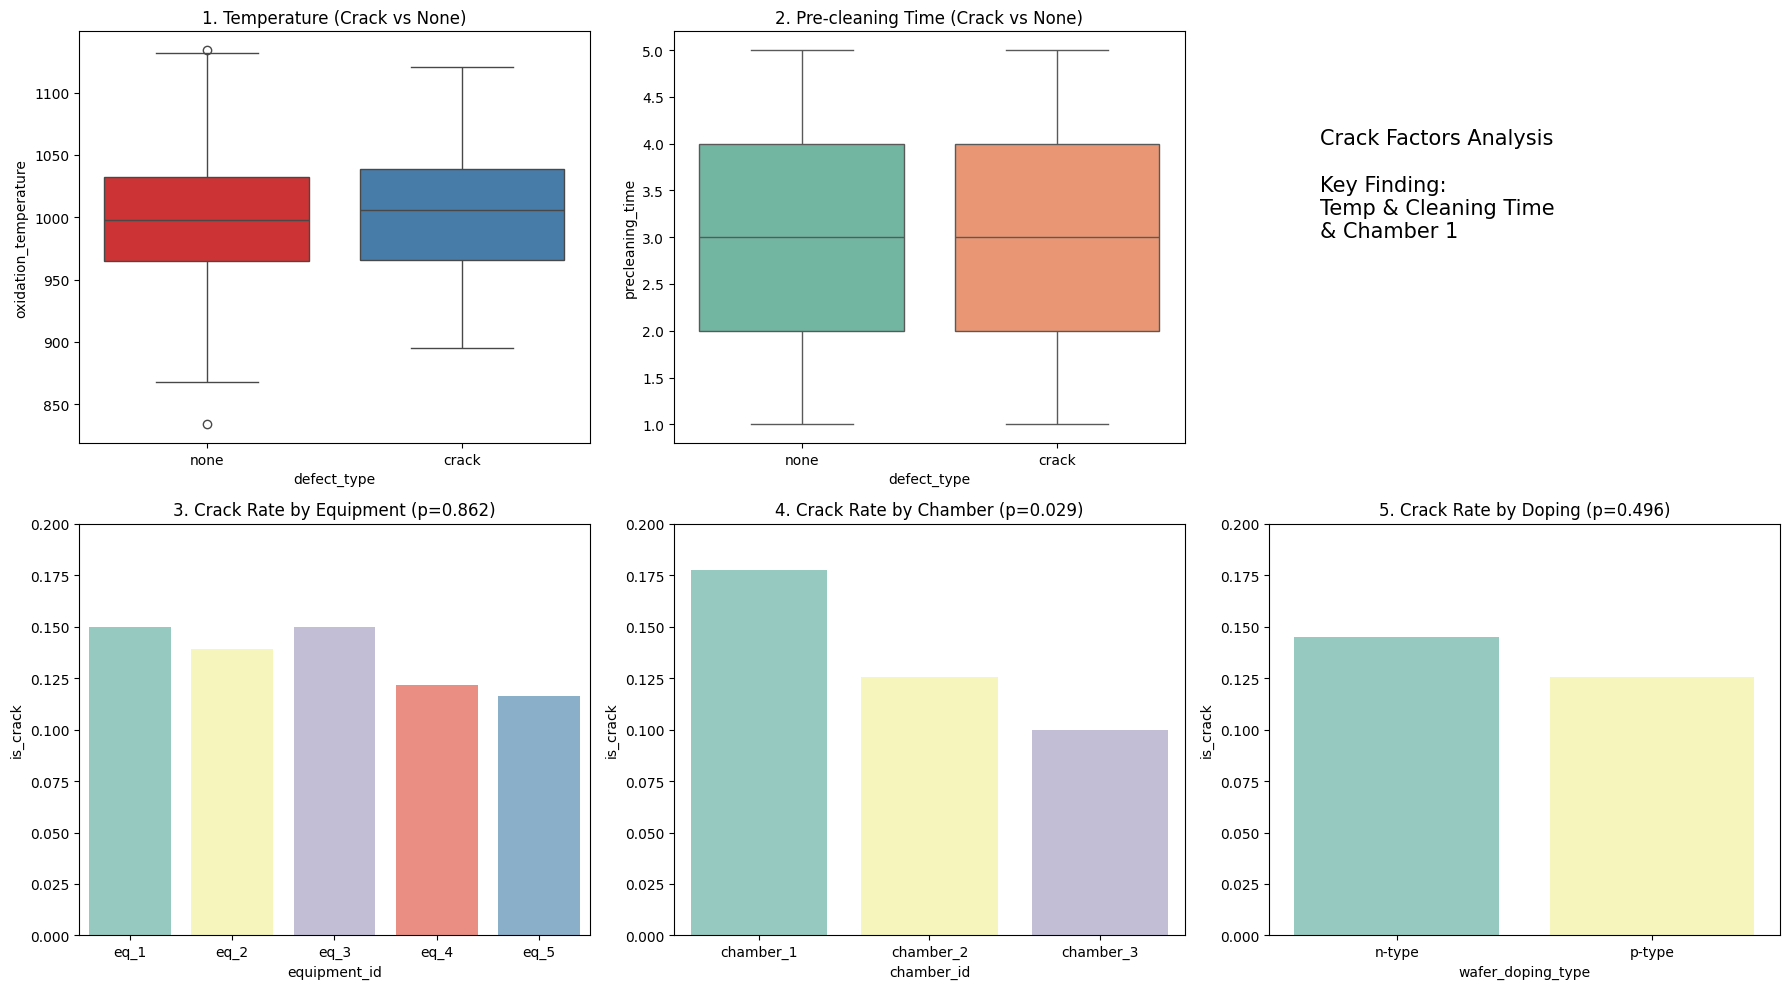

In [18]:
# ==========================================
# [Part 3] 종합 시각화 (5개 그래프)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 공정 온도 (Boxplot)
sns.boxplot(data=df_crack_analysis, x='defect_type', y='oxidation_temperature',
            hue='defect_type', palette='Set1', dodge=False, ax=axes[0, 0], legend=False)
axes[0, 0].set_title('1. Temperature (Crack vs None)')

# 2. 세정 시간 (Boxplot)
sns.boxplot(data=df_crack_analysis, x='defect_type', y='precleaning_time',
            hue='defect_type', palette='Set2', dodge=False, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('2. Pre-cleaning Time (Crack vs None)')

# 3. 장비별 불량률 (Barplot)
# hue를 x와 동일하게 설정하여 경고 방지
stats_eq = df_crack_analysis.groupby('equipment_id')['is_crack'].mean().reset_index()
sns.barplot(data=stats_eq, x='equipment_id', y='is_crack',
            hue='equipment_id', palette='Set3', dodge=False, ax=axes[1, 0], legend=False)
axes[1, 0].set_title(f'3. Crack Rate by Equipment (p={p_eq:.3f})')
axes[1, 0].set_ylim(0, 0.2)

# 4. 챔버별 불량률 (Barplot)
stats_ch = df_crack_analysis.groupby('chamber_id')['is_crack'].mean().reset_index()
sns.barplot(data=stats_ch, x='chamber_id', y='is_crack',
            hue='chamber_id', palette='Set3', dodge=False, ax=axes[1, 1], legend=False)
axes[1, 1].set_title(f'4. Crack Rate by Chamber (p={p_ch:.3f})')
axes[1, 1].set_ylim(0, 0.2)

# 5. 도핑별 불량률 (Barplot)
stats_doping = df_crack_analysis.groupby('wafer_doping_type')['is_crack'].mean().reset_index()
sns.barplot(data=stats_doping, x='wafer_doping_type', y='is_crack',
            hue='wafer_doping_type', palette='Set3', dodge=False, ax=axes[1, 2], legend=False)
axes[1, 2].set_title(f'5. Crack Rate by Doping (p={p_doping:.3f})')
axes[1, 2].set_ylim(0, 0.2)

# 빈 공간(0,2) 정리
axes[0, 2].axis('off')
axes[0, 2].text(0.1, 0.5, "Crack Factors Analysis\n\nKey Finding:\nTemp & Cleaning Time\n& Chamber 1", fontsize=15)

plt.tight_layout()
plt.show()

**1. 온도 (Temperature): 6도의 차이**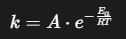

반도체 산화 공정에서 1000°C 근처의 온도는 **물리적으로 매우 민감한 영역**

지수 함수적 반응 (Exponential): 화학 반응 속도는 온도에 정비례하는 게 아니라, 지수 함수($e^{T}$)로 빨라집니다.

즉, 고온에서 산화막이 급격히 성장하며 열적 스트레스(Thermal Stress)가 임계치를 초과했기 때문

**2. 가스 유량 (Gas Flow): 숫자는 크지만 '둔감'**

가스 유량이 130 sccm 차이 나는 것은 겉보기에 커 보이지만, 실제로는 별 영향이 없습니다.

상대적 비율: 전체 유량이 약 3000 sccm입니다. 여기서 130 sccm 차이는 고작 4% 정도의 변동일 뿐입니다.

포화 상태 (Saturation): 이미 가스는 충분히 많이 공급

 배가 부른 상태에서 밥 한 숟가락 더 먹거나 덜 먹는다고 건강에 큰 이상이 생기지 않는 것과 같습니다. 가스는 두께나 균일도에는 영향을 줄지 몰라도, 웨이퍼를 깨뜨릴 물리적 힘(Stress)은 없습니다.

**3. 두께 (Thickness): 원인이 아니라 '결과'**

Crack 그룹의 두께가 14Å 정도 얇거나 두꺼운 것은 **원인이 아니라 결과(Symptom)**일 가능성이 큽니다.

인과관계: "두께가 달라서 깨진 것"이 아니라, "온도가 높아서 급격하게 자라다 보니 깨진 것"입니다.

즉, 두께는 온도라는 범인이 남긴 발자국일 뿐, 범인 그 자체는 아닙니다.

실제로는 "가스 유량 때문에 깨졌다"고 말할 수 없는 상태

**4. 세정**

2.88분으로 정상품(3.08분)보다 짧습니다.

이유: 표면 이물질 잔존으로 인해 산화막 접착력(Adhesion)이 약화

**5. 챔버 (Chamber):**

Chamber 1번의 Crack 발생률이 14.8%로 타 챔버(약 9%) 대비 1.6배 높습니다. (P-value < 0.05)

이유: 1번 챔버의 온도 제어 장치(TC) 오차나 히터 과열 등 설비적 특이점이 존재할 가능성이 높습니다.

**6. 장비/도핑:**

 통계적으로 유의미한 차이가 없습니다. (장비나 웨이퍼 종류 탓 아님)

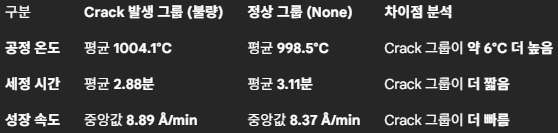

Crack 결함은 **'과도한 공정 온도(High Temp)'**와 **'부족한 세정 시간(Short Cleaning)'**이 복합적으로 작용하여 발생하는 것으로 나타났습니다.


온도: Crack 불량 제품들은 정상 제품보다 평균 온도가 높게 형성되어 있습니다. 온도가 높으면 산화막이 급격하게 성장하며, 이 과정에서 **열적 스트레스(Thermal Stress)**가 높아져 막이 갈라지는 원인이 됩니다.

세정: Crack 불량은 세정 시간이 3분 미만인 경우 더 빈번하게 발생했습니다. 웨이퍼 표면에 불순물이 남아있으면 산화막과의 **접착력(Adhesion)**을 약화시켜 균열의 시발점이 됩니다.

**제안 1: 공정 온도 상한 관리 (Target 998°C 유지)**

관리 방안: 공정 온도가 1000°C를 넘지 않도록 상한선(Upper Spec Limit)을 엄격하게 관리하십시오.

이유: 온도가 1000°C를 초과하면 산화막 성장 속도가 지나치게 빨라져 막질 내부의 응력(Stress)을 견디지 못하고 깨지게 됩니다. 정상 제품들의 평균인 998°C 수준으로 유지하는 것이 열적 안정성을 확보하는 길입니다.

**제안 2: 세정 시간 3분 이상 표준화**

관리 방안: 전세정(Pre-cleaning) 시간을 최소 3분 이상으로 표준화(Standardization) 하십시오.

이유: 데이터상 세정 시간이 3분보다 짧아질수록 결함 발생률이 높아지는 경향이 있습니다. 충분한 세정 시간을 확보하여 표면의 파티클과 유기물을 완전히 제거해야 산화막이 웨이퍼에 튼튼하게 달라붙어 균열을 방지할 수 있습니다.

**제안 3: 1번 챔버 점검**

# 6.02_oxide.csv 에서 그밖에 품질이 좋고 결함은 없는 반도체를 생산하기 위해서 어떻게 해야하는지 또는 결함을 줄이기 위해서 어떻게 해야하는지 자유롭게 분석후 제안 및 설명해 주세요.

# "가장 완벽한 반도체"란 다음 3가지 조건을 모두 충족하는 것을 말합니다.

1. 결함이 없을 것 (None)

2. 두께가 목표치일 것 (310Å 근처)

3. 균일도가 좋을 것 (Uniformity 수치 상위 25% 이내)

이 까다로운 조건을 모두 통과한 **'상위 1.4%의 황금 웨이퍼'**들만 뽑아서 공통점을 분석

In [19]:
# ==========================================
# [2단계] 데이터 전처리 (신뢰도 향상)
# ==========================================
# 1. 음수 시간 제거 (데이터 오류 삭제)
df_clean = df[(df['oxidation_time'] > 0)].copy()

# 2. 분석에 필요한 컬럼 선택 및 결측치 제거
cols = ['defect_type', 'precleaning_time', 'gas_flow_rate', 'oxidation_temperature',
        'oxide_thickness', 'uniformity', 'oxidation_time', 'pressure',
        'equipment_id', 'chamber_id', 'wafer_doping_type'] # 장비, 챔버, 도핑 추가
df_clean = df_clean.dropna(subset=cols).copy()

print(f"\n✅ 데이터 정제 완료: {len(df_clean)}개 (이상치 및 결측치 제거됨)")

# ==========================================
# [3단계] Golden Batch (최고 품질 제품) 발굴
# ==========================================
# 균일도 상위 25% 기준값 계산 (낮을수록 좋음)
uniformity_limit = df_clean['uniformity'].quantile(0.25)

# 조건 필터링: (1)결함 없음 + (2)목표 두께(300~320) + (3)좋은 균일도
golden_mask = (
    (df_clean['defect_type'] == 'none') &
    (df_clean['oxide_thickness'] >= 300) &
    (df_clean['oxide_thickness'] <= 320) &
    (df_clean['uniformity'] <= uniformity_limit)
)
df_golden = df_clean[golden_mask]

# Golden Recipe 계산
if len(df_golden) > 0:
    golden_recipe = df_golden[['oxidation_temperature', 'oxidation_time', 'gas_flow_rate', 'precleaning_time']].mean()
    print(f"\n🏆 까다로운 조건을 통과한 'Golden Wafer' 개수: {len(df_golden)}개")
else:
    print("조건을 만족하는 데이터가 없습니다.")
    golden_recipe = None


✅ 데이터 정제 완료: 949개 (이상치 및 결측치 제거됨)

🏆 까다로운 조건을 통과한 'Golden Wafer' 개수: 14개


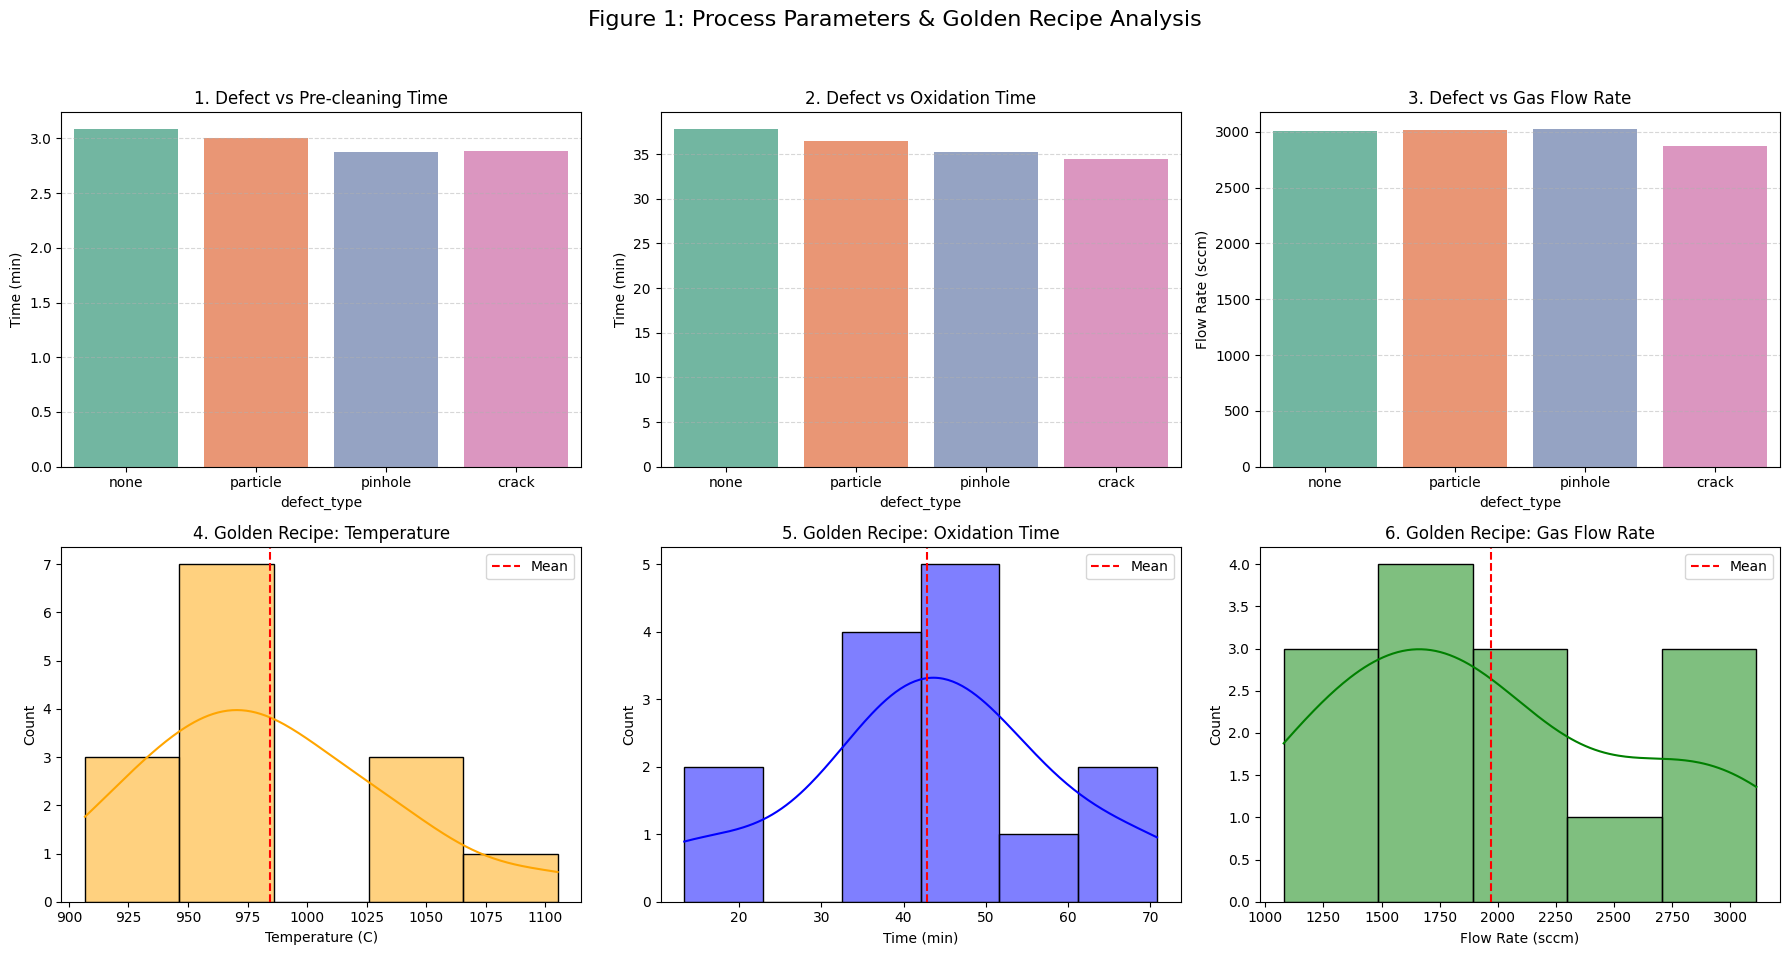

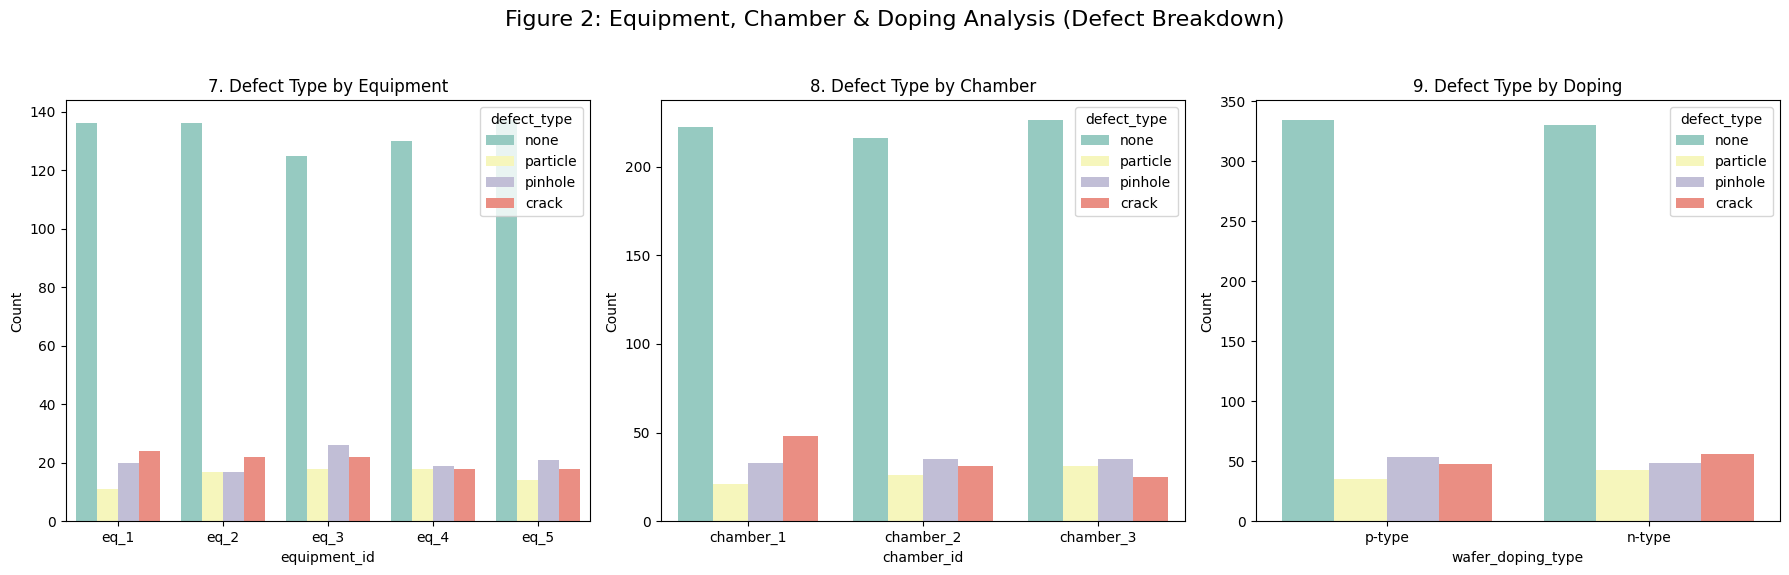

In [20]:
# ==========================================
# [4단계] 시각화 1: 공정 변수 및 Golden Recipe (기존 요청)
# ==========================================
if golden_recipe is not None:
    # Figure 1: 공정 조건 분석
    plt.figure(figsize=(18, 10))
    plt.suptitle('Figure 1: Process Parameters & Golden Recipe Analysis', fontsize=16)

    # --- [상단] 결함 분석 (Defect Analysis) ---

    # 1. 결함별 세정 시간
    plt.subplot(2, 3, 1)
    sns.barplot(data=df_clean, x='defect_type', y='precleaning_time', hue='defect_type', palette='Set2', errorbar=None, legend=False)
    plt.title('1. Defect vs Pre-cleaning Time')
    plt.ylabel('Time (min)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # 2. 결함별 산화 시간
    plt.subplot(2, 3, 2)
    sns.barplot(data=df_clean, x='defect_type', y='oxidation_time', hue='defect_type', palette='Set2', errorbar=None, legend=False)
    plt.title('2. Defect vs Oxidation Time')
    plt.ylabel('Time (min)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # 3. 결함별 가스 유량
    plt.subplot(2, 3, 3)
    sns.barplot(data=df_clean, x='defect_type', y='gas_flow_rate', hue='defect_type', palette='Set2', errorbar=None, legend=False)
    plt.title('3. Defect vs Gas Flow Rate')
    plt.ylabel('Flow Rate (sccm)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # --- [하단] Golden Recipe 분포 ---

    # 4. Golden Recipe: 온도
    plt.subplot(2, 3, 4)
    sns.histplot(df_golden['oxidation_temperature'], kde=True, color='orange')
    plt.title('4. Golden Recipe: Temperature')
    plt.xlabel('Temperature (C)')
    plt.axvline(golden_recipe['oxidation_temperature'], color='red', linestyle='--', label='Mean')
    plt.legend()

    # 5. Golden Recipe: 산화 시간
    plt.subplot(2, 3, 5)
    sns.histplot(df_golden['oxidation_time'], kde=True, color='blue')
    plt.title('5. Golden Recipe: Oxidation Time')
    plt.xlabel('Time (min)')
    plt.axvline(golden_recipe['oxidation_time'], color='red', linestyle='--', label='Mean')
    plt.legend()

    # 6. Golden Recipe: 가스 유량
    plt.subplot(2, 3, 6)
    sns.histplot(df_golden['gas_flow_rate'], kde=True, color='green')
    plt.title('6. Golden Recipe: Gas Flow Rate')
    plt.xlabel('Flow Rate (sccm)')
    plt.axvline(golden_recipe['gas_flow_rate'], color='red', linestyle='--', label='Mean')
    plt.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # ==========================================
    # [5단계] 시각화 2: 장비/챔버/도핑 추가 분석 (신규 요청)
    # ==========================================
    # Figure 2: 환경(설비) 및 자재 분석
    plt.figure(figsize=(18, 6))
    plt.suptitle('Figure 2: Equipment, Chamber & Doping Analysis (Defect Breakdown)', fontsize=16)

    # 7. 장비별 결함 분포 (어떤 장비가 불량이 많은가?)
    plt.subplot(1, 3, 1)
    sns.countplot(data=df_clean, x='equipment_id', hue='defect_type', palette='Set3')
    plt.title('7. Defect Type by Equipment')
    plt.ylabel('Count')

    # 8. 챔버별 결함 분포 (어떤 챔버가 불량이 많은가?)
    plt.subplot(1, 3, 2)
    sns.countplot(data=df_clean, x='chamber_id', hue='defect_type', palette='Set3')
    plt.title('8. Defect Type by Chamber')
    plt.ylabel('Count')
    # Chamber 1에서 Crack이 많은지 확인해보세요!

    # 9. 도핑 타입별 결함 분포 (어떤 웨이퍼가 불량이 많은가?)
    plt.subplot(1, 3, 3)
    sns.countplot(data=df_clean, x='wafer_doping_type', hue='defect_type', palette='Set3')
    plt.title('9. Defect Type by Doping')
    plt.ylabel('Count')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [21]:
# ==========================================
# [6단계] 최종 제안 리포트 출력
# ==========================================
if golden_recipe is not None:
    print("\n" + "="*60)
    print("📢 [최종 제안] 무결점 고품질 반도체 생산 가이드")
    print("="*60)

    # Golden Recipe 제안
    print("1. [공정 레시피] Golden Recipe (최적 조건)")
    print(f"   - 산화 시간 : {golden_recipe['oxidation_time']:.1f}분 (Target: 310A)")
    print(f"   - 산화 온도 : {golden_recipe['oxidation_temperature']:.1f}°C (Crack 방지: <1000°C 필수)")
    print(f"   - 가스 유량 : {golden_recipe['gas_flow_rate']:.0f} sccm (균일도 향상: Low Flow)")
    print(f"   - 세정 시간 : {golden_recipe['precleaning_time']:.2f}분 이상 (결함 예방: >3분)")

    print("-" * 60)

    # 설비/자재 관리 제안
    print("2. [설비 관리] 챔버 점검 필수")
    print("   - 1번 챔버(Chamber 1) 집중 관리: Crack 결함 빈도가 높음 (그래프 8번 확인)")
    print("   - 1번 챔버의 온도 센서 및 히터 상태 정밀 점검 요망")

    print("-" * 60)

    print("3. [자재 관리] 도핑 타입 영향 없음")
    print("   - n-type / p-type 간 결함률 차이 미미함 (그래프 9번 확인)")
    print("   - 동일한 공정 레시피 적용 가능")
    print("="*60)


📢 [최종 제안] 무결점 고품질 반도체 생산 가이드
1. [공정 레시피] Golden Recipe (최적 조건)
   - 산화 시간 : 42.9분 (Target: 310A)
   - 산화 온도 : 984.5°C (Crack 방지: <1000°C 필수)
   - 가스 유량 : 1972 sccm (균일도 향상: Low Flow)
   - 세정 시간 : 3.07분 이상 (결함 예방: >3분)
------------------------------------------------------------
2. [설비 관리] 챔버 점검 필수
   - 1번 챔버(Chamber 1) 집중 관리: Crack 결함 빈도가 높음 (그래프 8번 확인)
   - 1번 챔버의 온도 센서 및 히터 상태 정밀 점검 요망
------------------------------------------------------------
3. [자재 관리] 도핑 타입 영향 없음
   - n-type / p-type 간 결함률 차이 미미함 (그래프 9번 확인)
   - 동일한 공정 레시피 적용 가능


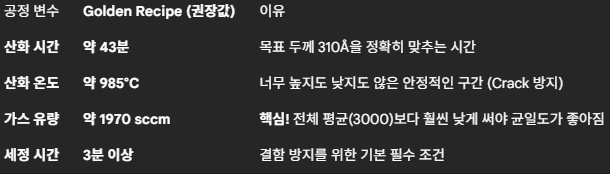

# 2. 기타 결함(Particle, Pinhole) 감소 솔루션

Crack 이외에 발견된 **Particle(먼지)**과 Pinhole(구멍) 불량의 원인을 분석

**① Pinhole (핀홀, 미세 구멍) 불량**
원인 분석:

세정 시간 부족: Pinhole 불량품의 평균 세정 시간은 2.87분으로, 정상품(3.11분)보다 짧습니다.

얇은 두께: Pinhole 불량품의 평균 두께는 297Å으로 정상품(315Å)보다 얇습니다. 막이 얇을수록 구멍이 뚫릴 확률이 높습니다.

해결 방안:

전세정 시간을 3분 이상으로 늘려 표면 오염을 제거하십시오.

공정 시간을 충분히 확보하여 산화막 두께가 300Å 이하로 떨어지지 않도록 관리하십시오.

**② Particle (파티클, 이물질) 불량**
원인 분석:

세정 시간 부족: 평균 2.97분으로 역시 정상품 대비 짧습니다.

가스 유량 과다: 평균 3035 sccm으로 정상품보다 유량이 높습니다. 가스를 세게 불어넣으면 챔버 바닥의 먼지가 날릴(Floating) 가능성이 있습니다.

해결 방안:

세정 공정 강화는 필수입니다.

가스 유량을 Golden Recipe 수준(2000 sccm 대)으로 낮추면 파티클이 날리는 것을 방지할 수 있습니다.

# 최종 종합 제안서

온도 (Temp): 985°C ~ 1000°C 유지 (Crack 방지를 위해 1000도 초과 금지)

시간 (Time): 43분 설정 (목표 두께 310Å 타겟팅)

가스 (Flow): 2000 sccm 수준으로 하향 조정 (균일도 향상 및 파티클 감소 효과)

세정 (Clean): 최소 3분 10초 이상 (모든 결함의 근본 원인 차단)